# Validation notebook (V1, V2, V3)

This notebook runs all three validation scripts.
Then it prints a short summary and shows the saved figures.


## Setup

Import helper functions used by all sections below.


In [7]:
from pathlib import Path

from skin_diffusion.notebook_helpers import (
    setup_repo_root,
    run_module,
    list_images,
    show_images_grid,
    find_latest_run_bundle_dir,
    assert_paths_exist,
    load_json,
)

# go to project root
repo_root = setup_repo_root()
print('repo_root:', repo_root)


repo_root: C:\Users\nwals\Documents\COMP3931_IndividualProject


## Run scripts

For each regime we:
1. run the validation script,
2. locate run outputs,
3. load metrics + stability info.


In [8]:
cases = [
    ('V1', 'scripts.sim.validate_v1', 'configs/sim/v1_baseline.yaml', Path('figures/validation/v1'), Path('outputs/sim/v1')),
    ('V2', 'scripts.sim.validate_v2', 'configs/sim/v2_layers_clearance.yaml', Path('figures/validation/v2'), Path('outputs/sim/v2')),
    ('V3', 'scripts.sim.validate_v3', 'configs/sim/v3_hetero_patch_timeDecay.yaml', Path('figures/validation/v3'), Path('outputs/sim/v3')),
]

results = {}

for case in cases:
    name = case[0]
    module = case[1]
    cfg = case[2]
    fig_dir = case[3]
    out_base = case[4]

    # run script
    run_module(module, ['--config', cfg], repo_root=repo_root)

    # find latest run output
    run_dir = find_latest_run_bundle_dir(out_base)
    required = [run_dir / 'fields.npz', run_dir / 'meta.json', run_dir / 'metrics.json']
    assert_paths_exist(required)

    # load summary files
    metrics = load_json(run_dir / 'metrics.json')
    meta = load_json(run_dir / 'meta.json')
    images = list_images(fig_dir)

    results[name] = {
        'run_dir': run_dir,
        'fig_dir': fig_dir,
        'n_images': len(images),
        'metrics': {
            'J_ss': metrics.get('J_ss'),
            'Tlag': metrics.get('Tlag'),
            'P': metrics.get('P'),
        },
        'stability': meta.get('stability', {}),
    }

results


running: c:\Users\nwals\Documents\COMP3931_IndividualProject\.venv\Scripts\python.exe -m scripts.sim.validate_v1 --config configs/sim/v1_baseline.yaml
running: c:\Users\nwals\Documents\COMP3931_IndividualProject\.venv\Scripts\python.exe -m scripts.sim.validate_v2 --config configs/sim/v2_layers_clearance.yaml
running: c:\Users\nwals\Documents\COMP3931_IndividualProject\.venv\Scripts\python.exe -m scripts.sim.validate_v3 --config configs/sim/v3_hetero_patch_timeDecay.yaml


{'V1': {'run_dir': WindowsPath('outputs/sim/v1/20260212_180918'),
  'fig_dir': WindowsPath('figures/validation/v1'),
  'n_images': 7,
  'metrics': {'J_ss': 1.4215015597532132,
   'Tlag': 0.07925173129882652,
   'P': 1.4215015597532132},
  'stability': {'Dmax': 1.0,
   'dt_diff_max': 2.5e-05,
   'kmax': 0.0,
   'dt_react_max': None}},
 'V2': {'run_dir': WindowsPath('outputs/sim/v2'),
  'fig_dir': WindowsPath('figures/validation/v2'),
  'n_images': 10,
  'metrics': {'J_ss': 7.02947412881382e-06,
   'Tlag': 0.8068818917257825,
   'P': 7.02947412881382e-06},
  'stability': {'Dmax': 1.0,
   'dt_diff_max': 2.5e-05,
   'kmax': 0.2,
   'dt_react_max': 5.0}},
 'V3': {'run_dir': WindowsPath('outputs/sim/v3'),
  'fig_dir': WindowsPath('figures/validation/v3'),
  'n_images': 15,
  'metrics': {'J_ss': 0.574958991753621, 'Tlag': None, 'P': 0.574958991753621},
  'stability': {'Dmax': 1.0,
   'dt_diff_max': 2.5e-05,
   'kmax': 0.0,
   'dt_react_max': None}}}

## Summary

Quick text summary for each regime.


In [9]:
for name in results:
    r = results[name]
    print('=' * 60)
    print(name)
    print('run_dir:', r['run_dir'])
    print('figures:', r['n_images'])
    print('metrics:', r['metrics'])
    print('stability:', r['stability'])


V1
run_dir: outputs\sim\v1\20260212_180918
figures: 7
metrics: {'J_ss': 1.4215015597532132, 'Tlag': 0.07925173129882652, 'P': 1.4215015597532132}
stability: {'Dmax': 1.0, 'dt_diff_max': 2.5e-05, 'kmax': 0.0, 'dt_react_max': None}
V2
run_dir: outputs\sim\v2
figures: 10
metrics: {'J_ss': 7.02947412881382e-06, 'Tlag': 0.8068818917257825, 'P': 7.02947412881382e-06}
stability: {'Dmax': 1.0, 'dt_diff_max': 2.5e-05, 'kmax': 0.2, 'dt_react_max': 5.0}
V3
run_dir: outputs\sim\v3
figures: 15
metrics: {'J_ss': 0.574958991753621, 'Tlag': None, 'P': 0.574958991753621}
stability: {'Dmax': 1.0, 'dt_diff_max': 2.5e-05, 'kmax': 0.0, 'dt_react_max': None}


## Figures

Shows up to 9 images for each regime.


V1: 7 images


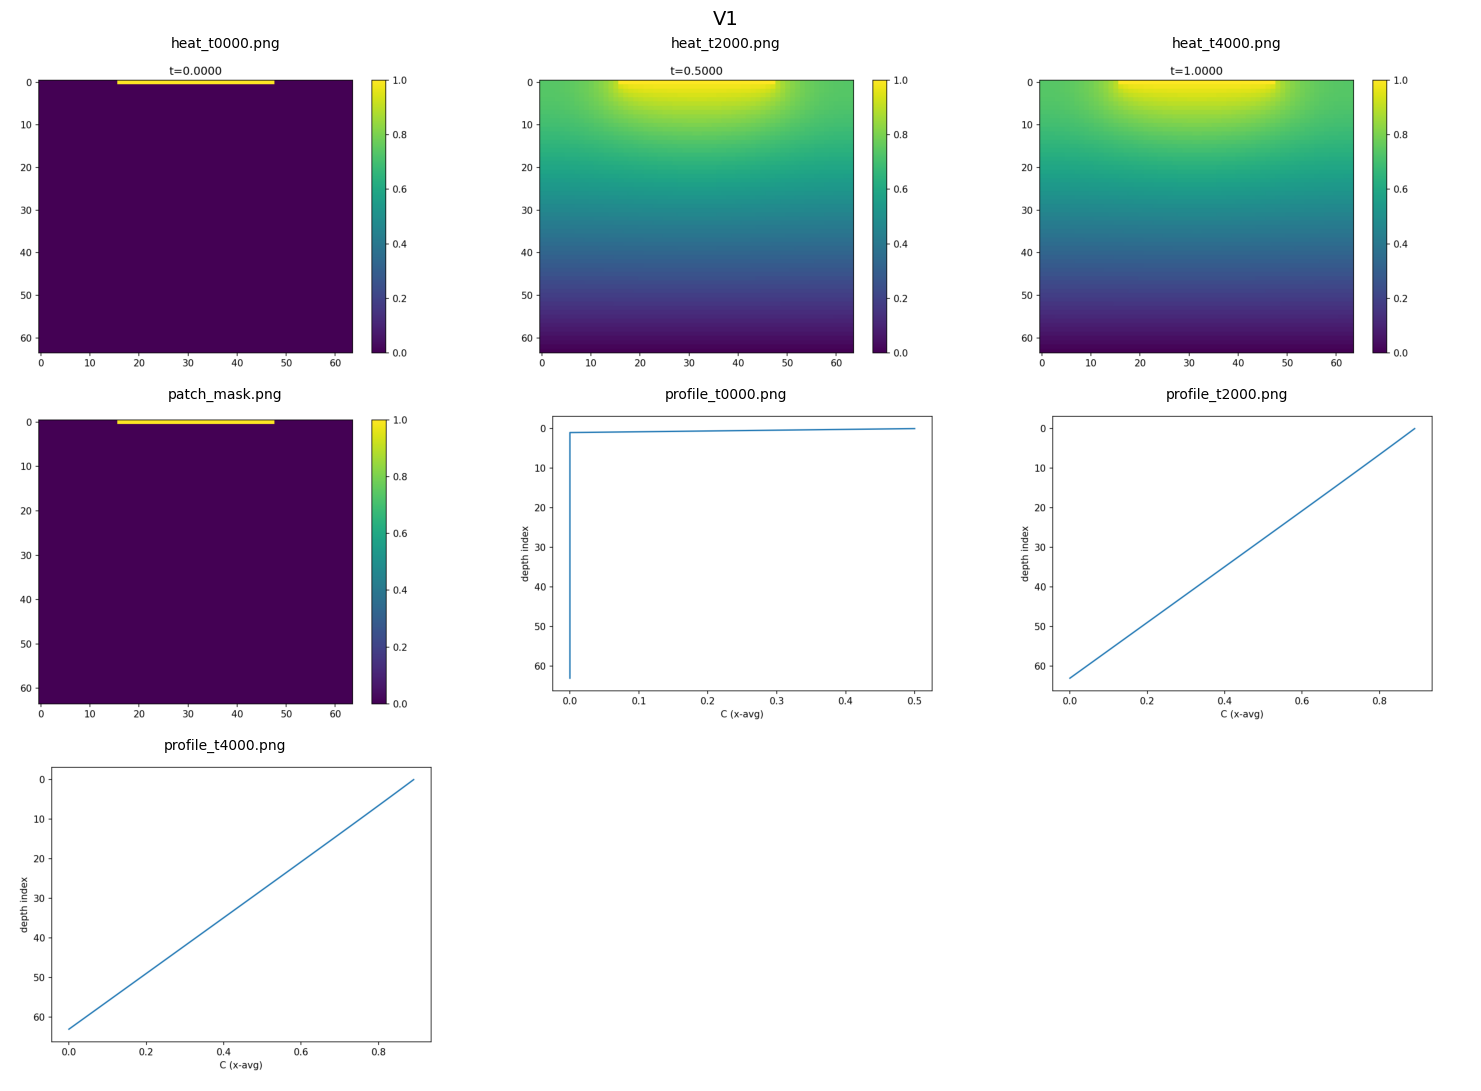

V2: 10 images


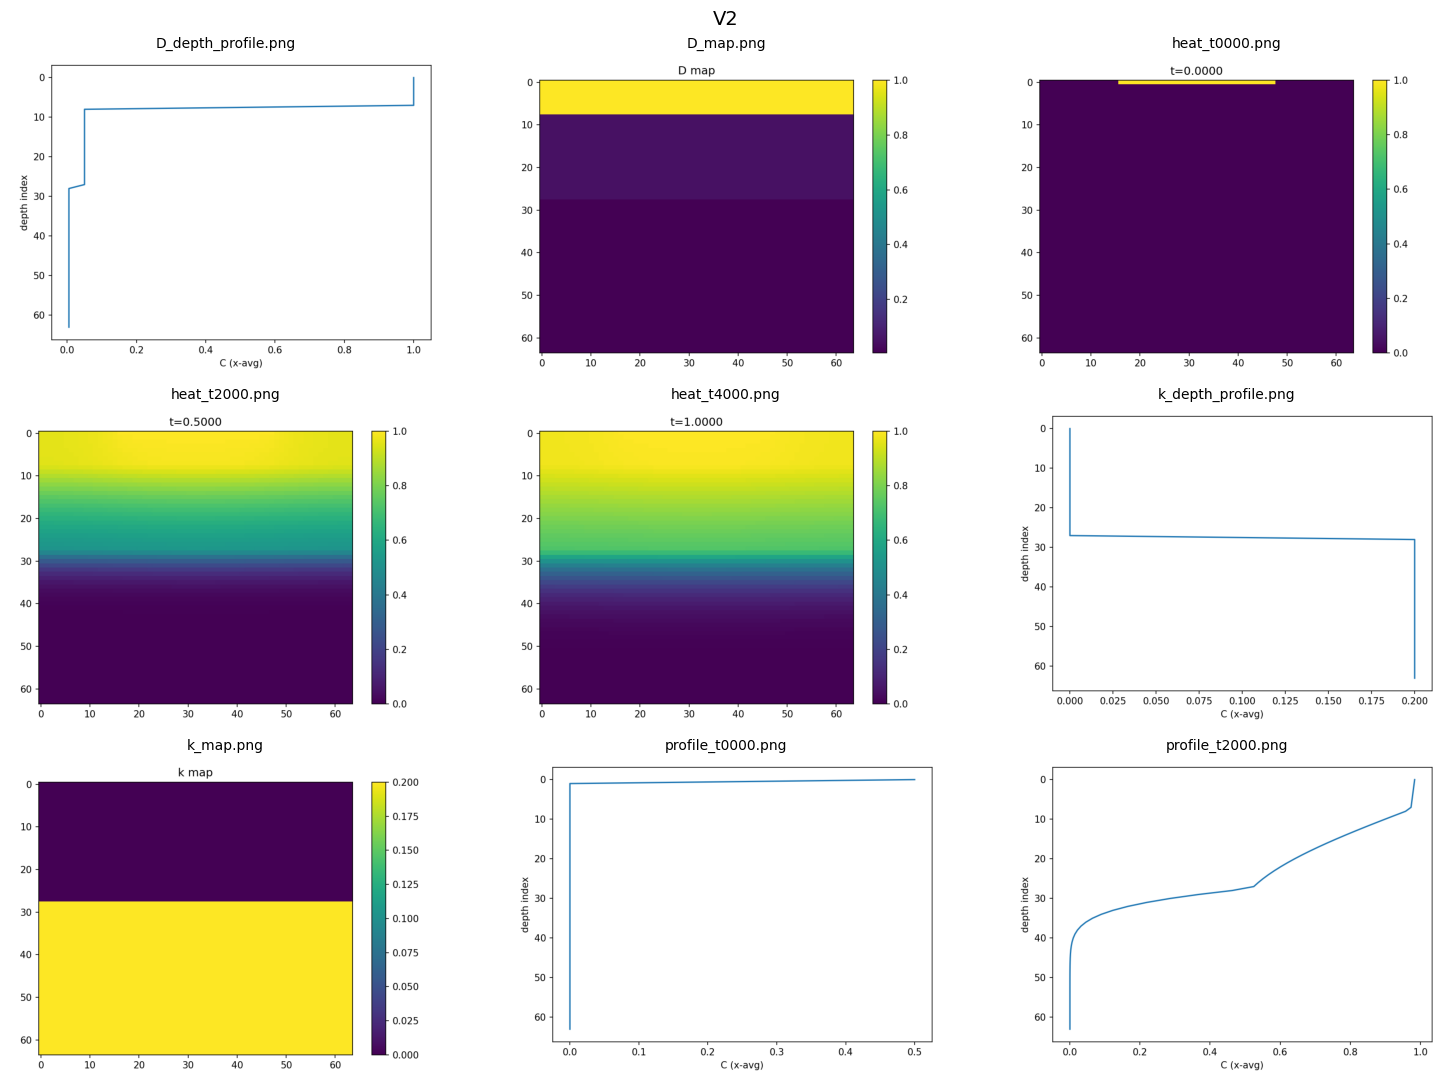

V3: 15 images


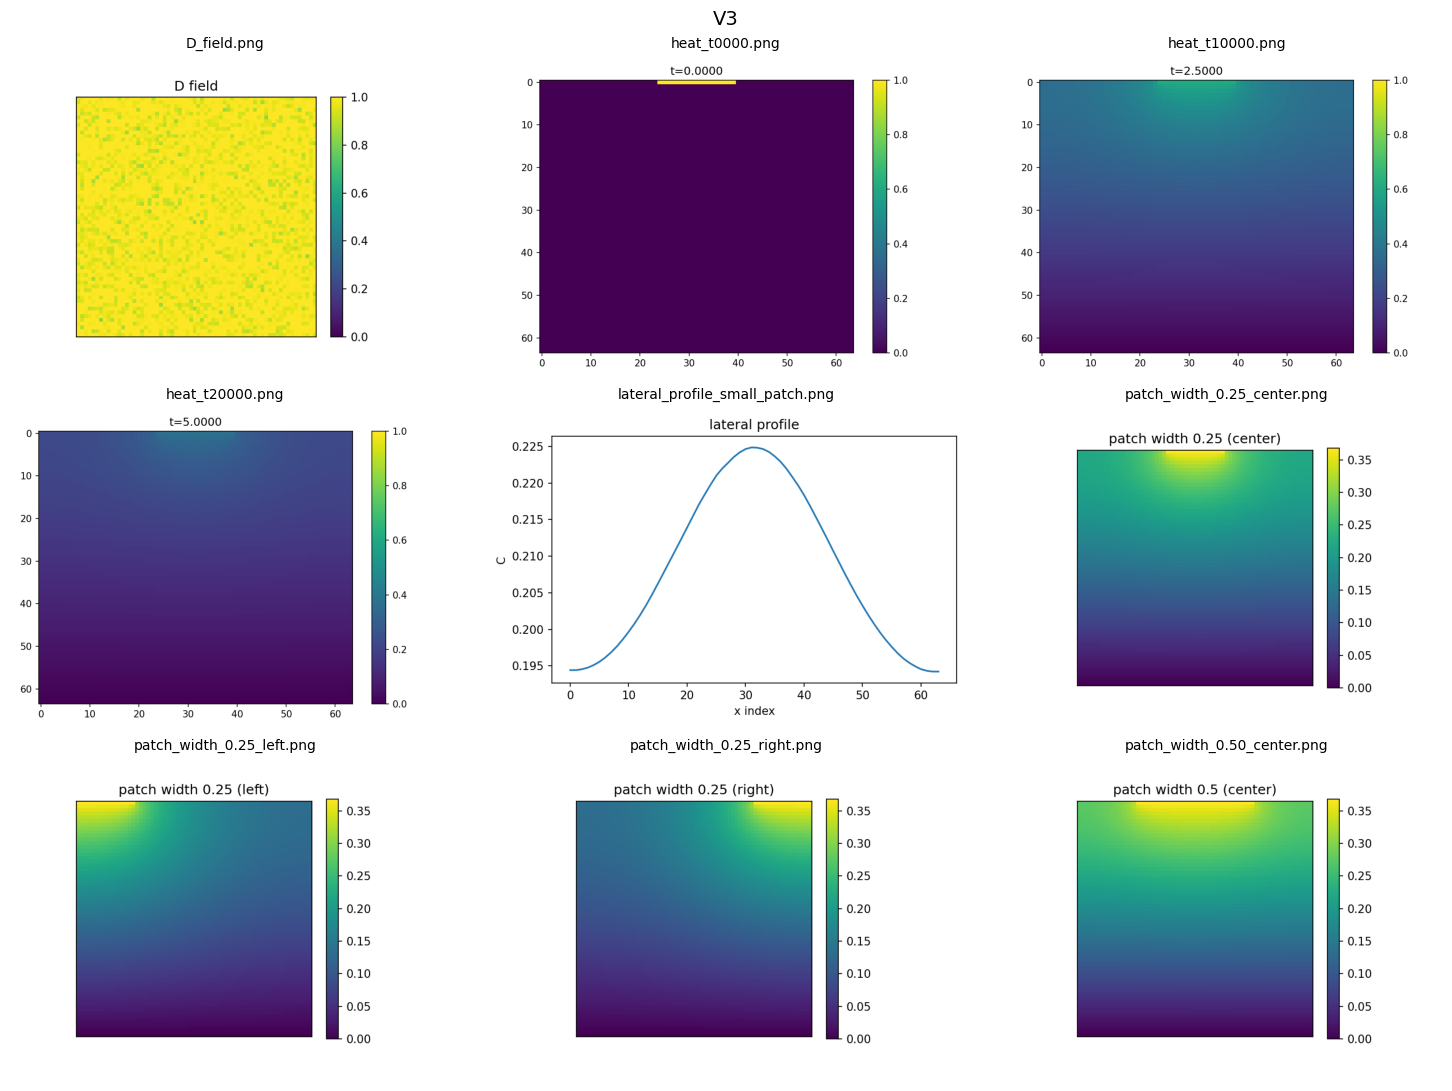

In [11]:
for name in results:
    r = results[name]
    imgs = list_images(r['fig_dir'])
    print(f'{name}: {len(imgs)} images')
    show_images_grid(imgs, cols=3, max_images=9, title=name)
